In [ ]:
import pandas as pd


###Import Raw Data

In [9]:
from google.colab import files

uploaded = files.upload()

Saving pizza_sales_excel_file.xlsx to pizza_sales_excel_file.xlsx


In [13]:
import pandas as pd

df = pd.read_excel("pizza_sales_excel_file.xlsx")

In [14]:
import os

os.listdir()

['.config', 'pizza_sales_excel_file.xlsx', 'sample_data']

In [15]:
df = pd.read_excel("pizza_sales_excel_file.xlsx")

In [17]:
!pip install openpyxl

In [18]:
import os

print(os.listdir('/content'))

['.config', 'pizza_sales_excel_file.xlsx', 'sample_data']


In [19]:
import pandas as pd

In [20]:
df = pd.read_excel("pizza_sales_excel_file.xlsx", engine="openpyxl")

In [21]:
df.head()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,2015-01-01,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   pizza_id           48620 non-null  int64         
 1   order_id           48620 non-null  int64         
 2   pizza_name_id      48620 non-null  object        
 3   quantity           48620 non-null  int64         
 4   order_date         48620 non-null  datetime64[ns]
 5   order_time         48620 non-null  object        
 6   unit_price         48620 non-null  float64       
 7   total_price        48620 non-null  float64       
 8   pizza_size         48620 non-null  object        
 9   pizza_category     48620 non-null  object        
 10  pizza_ingredients  48620 non-null  object        
 11  pizza_name         48620 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(6)
memory usage: 4.5+ MB


###Data types in Raw data

In [23]:
df.dtypes

,0
pizza_id,int64
order_id,int64
pizza_name_id,object
quantity,int64
order_date,datetime64[ns]
order_time,object
unit_price,float64
total_price,float64
pizza_size,object
pizza_category,object


In [24]:
df.describe()

,pizza_id,order_id,quantity,order_date,unit_price,total_price
count,48620.000000,48620.000000,48620.000000,48620,48620.000000,48620.000000
mean,24310.500000,10701.479761,1.019622,2015-06-29 11:03:43.611682560,16.494132,16.821474
min,1.000000,1.000000,1.000000,2015-01-01 00:00:00,9.750000,9.750000
25%,12155.750000,5337.000000,1.000000,2015-03-31 00:00:00,12.750000,12.750000
50%,24310.500000,10682.500000,1.000000,2015-06-28 00:00:00,16.500000,16.500000
75%,36465.250000,16100.000000,1.000000,2015-09-28 00:00:00,20.250000,20.500000
max,48620.000000,21350.000000,4.000000,2015-12-31 00:00:00,35.950000,83.000000
std,14035.529381,6180.119770,0.143077,NaN,3.621789,4.437398


###KPI's

In [25]:
total_revenue = df['total_price'].sum()
total_pizzas_sold = df['quantity'].sum()
total_orders = df['order_id'].nunique()
avg_order_value = total_revenue / total_orders
avg_pizzas_per_order = total_pizzas_sold / total_orders

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Pizzas Sold: {total_pizzas_sold:,}")
print(f"Total Orders: {total_orders:,}")
print(f"Avg Order Value: ${avg_order_value:,.2f}")
print(f"Average Pizza per Order : {avg_pizzas_per_order:.2f}")

Total Revenue: $817,860.05
Total Pizzas Sold: 49,574
Total Orders: 21,350
Avg Order Value: $38.31
Average Pizza per Order : 2.32


###Charts

###Ingredient Analysis

In [26]:
ingredient = (
    df['pizza_ingredients']
        .str.split(',')
        .explode()
        .str.strip()
        .value_counts()
        .reset_index()
        .rename(columns={'index': 'Ingredient', 'pizza_ingredients': 'Count'})
)

print(ingredient.head(15))

                Count  count
0              Garlic  27422
1            Tomatoes  26601
2          Red Onions  19547
3         Red Peppers  16284
4   Mozzarella Cheese  10333
5           Pepperoni  10300
6             Spinach  10012
7           Mushrooms   9624
8             Chicken   8443
9           Capocollo   6572
10       Green Olives   6174
11         Artichokes   5682
12   Jalapeno Peppers   5643
13      Green Peppers   5224
14        Feta Cheese   4748


### Daily Trend_Total Orders

In [30]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Test')

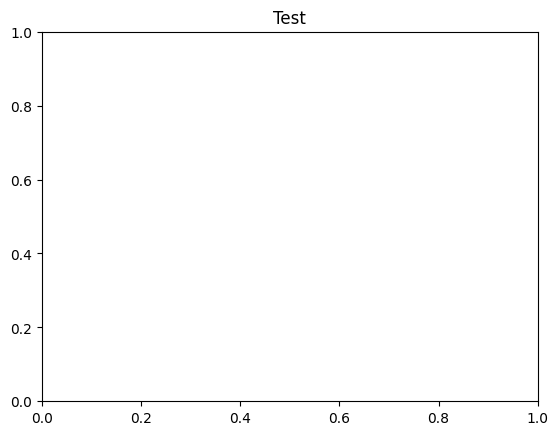

In [31]:
plt.title("Test")

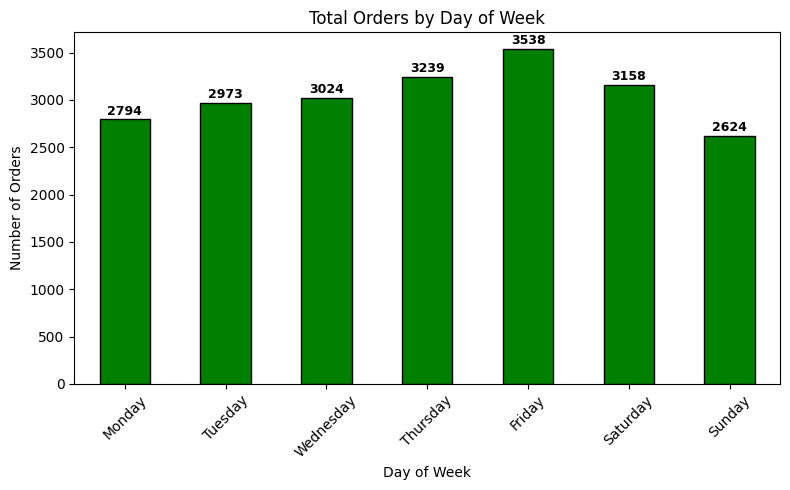

In [32]:
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)

df['day_name'] = df['order_date'].dt.day_name()

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

df['day_name'] = pd.Categorical(df['day_name'], categories=weekday_order, ordered=True)

orders_by_day = df.groupby('day_name', observed=False)['order_id'].nunique()

ax = orders_by_day.plot(kind='bar', figsize=(8,5), color='green', edgecolor='black')

plt.title("Total Orders by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

for i, val in enumerate(orders_by_day):
    plt.text(i, val + 20, str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

###Daily Trend - Total Revenue

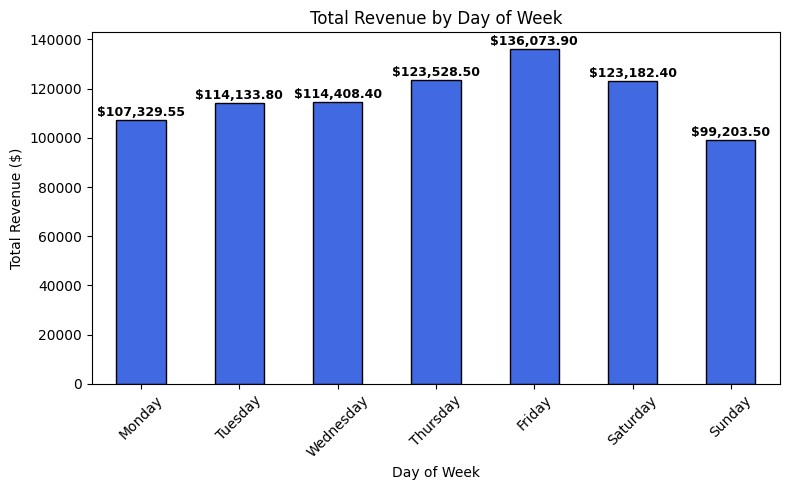

In [33]:
# Convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)

# Extract day name
df['day_name'] = df['order_date'].dt.day_name()

# Arrange days in correct order
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

df['day_name'] = pd.Categorical(df['day_name'],
                                categories=weekday_order,
                                ordered=True)

# Calculate Total Revenue by Day
revenue_by_day = df.groupby('day_name', observed=False)['total_price'].sum()

# Plot Bar Chart
ax = revenue_by_day.plot(kind='bar',
                         figsize=(8,5),
                         color='royalblue',
                         edgecolor='black')

# Chart Title and Labels
plt.title("Total Revenue by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=45)

# Display Revenue Values on Bars
for i, val in enumerate(revenue_by_day):
    plt.text(i,
             val + 500,
             f"${val:,.2f}",
             ha='center',
             va='bottom',
             fontsize=9,
             fontweight='bold')

plt.tight_layout()
plt.show()

###Hourly Trends - Total Orders

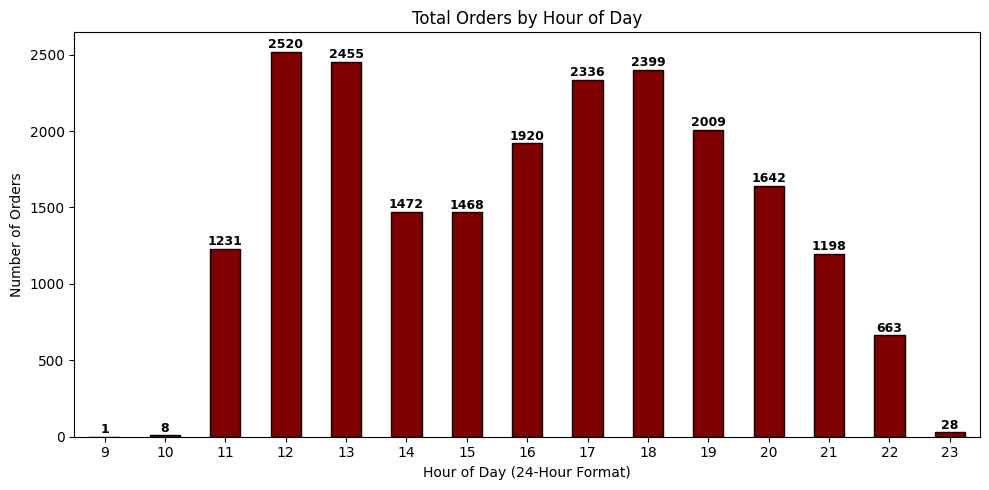

In [34]:
df['order_time'] = pd.to_datetime(df['order_time'], format='%H:%M:%S')

df['order_hour'] = df['order_time'].dt.hour

orders_by_hour = df.groupby('order_hour', observed=False)['order_id'].nunique()

ax = orders_by_hour.plot(kind='bar', figsize=(10,5), color='maroon', edgecolor='black')

plt.title("Total Orders by Hour of Day")
plt.xlabel("Hour of Day (24-Hour Format)")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)

for i, val in enumerate(orders_by_hour):
    plt.text(i, val + 5, str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

###Monthly Trends - Total Orders

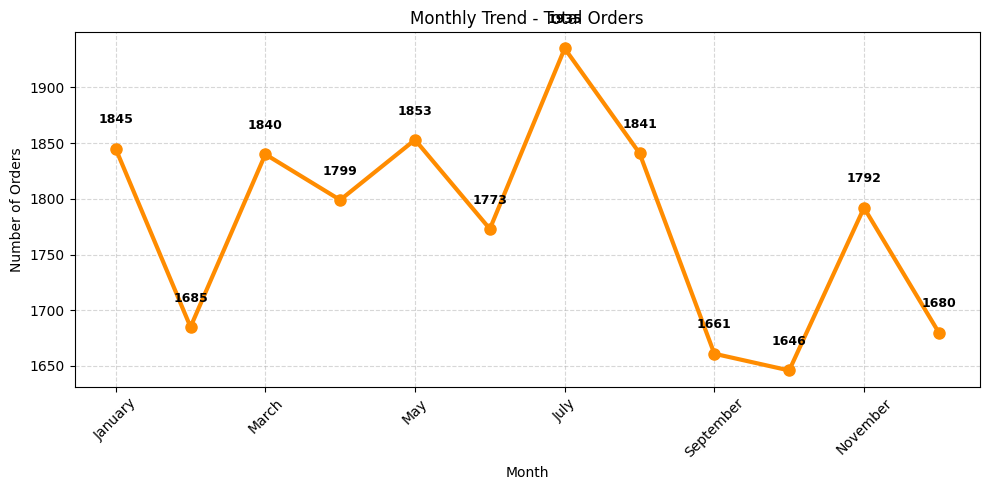

In [38]:
# Convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)

# Extract Month Name
df['month_name'] = df['order_date'].dt.month_name()

# Arrange months in correct order
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

df['month_name'] = pd.Categorical(df['month_name'],
                                  categories=month_order,
                                  ordered=True)

# Calculate Total Orders by Month
orders_by_month = df.groupby('month_name', observed=False)['order_id'].nunique()

# Plot Line Chart
ax = orders_by_month.plot(kind='line',
                          figsize=(10,5),
                          color='darkorange',
                          marker='o',
                          linewidth=3,
                          markersize=8)

# Chart Title and Labels
plt.title("Monthly Trend - Total Orders")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

# Display values on each point
for i, val in enumerate(orders_by_month):
    plt.text(i, val + 20, str(val),
             ha='center',
             va='bottom',
             fontsize=9,
             fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

###Percentage of Sales by Category

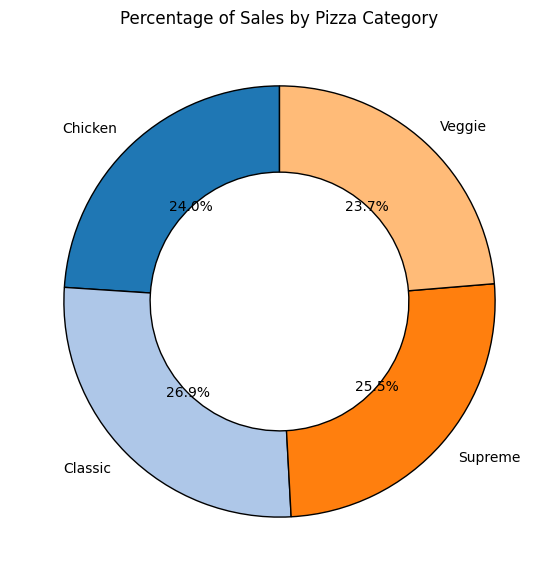

In [39]:
# % of Sales by Category

category_sales = df.groupby('pizza_category')['total_price'].sum()

category_pct = category_sales / category_sales.sum() * 100

plt.figure(figsize=(7,7))

colors = plt.get_cmap('tab20').colors  # nice color palette

plt.pie(category_pct,
        labels=category_pct.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        wedgeprops={'edgecolor':'black', 'width':0.4})

plt.title("Percentage of Sales by Pizza Category")

plt.show()

###Percentage Sales by Pizza Size and Category

In [43]:
import seaborn as sns

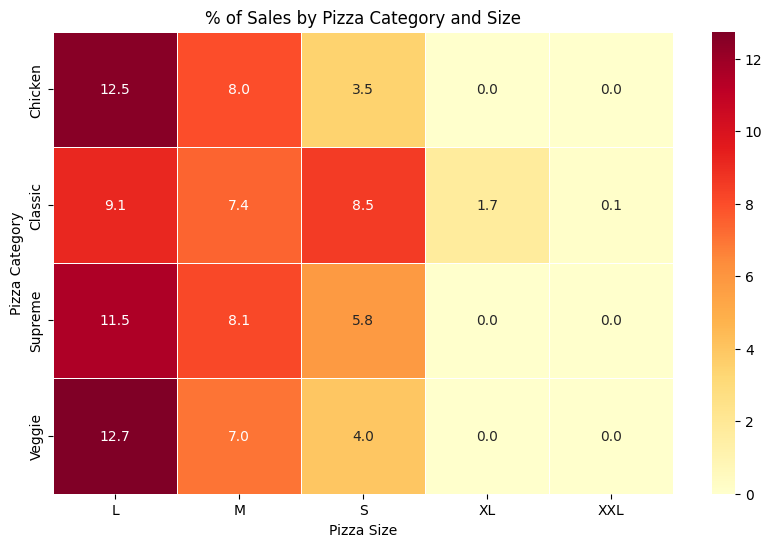

In [44]:
# % Sales by Pizza Size & Category

sales_pivot = df.pivot_table(
    index='pizza_category',
    columns='pizza_size',
    values='total_price',
    aggfunc='sum',
    fill_value=0
)

sales_pct = sales_pivot / sales_pivot.sum().sum() * 100

plt.figure(figsize=(10,6))

sns.heatmap(sales_pct, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5)

plt.title("% of Sales by Pizza Category and Size")
plt.ylabel("Pizza Category")
plt.xlabel("Pizza Size")

plt.show()

###Total Pizza Sold by Pizza Catergory

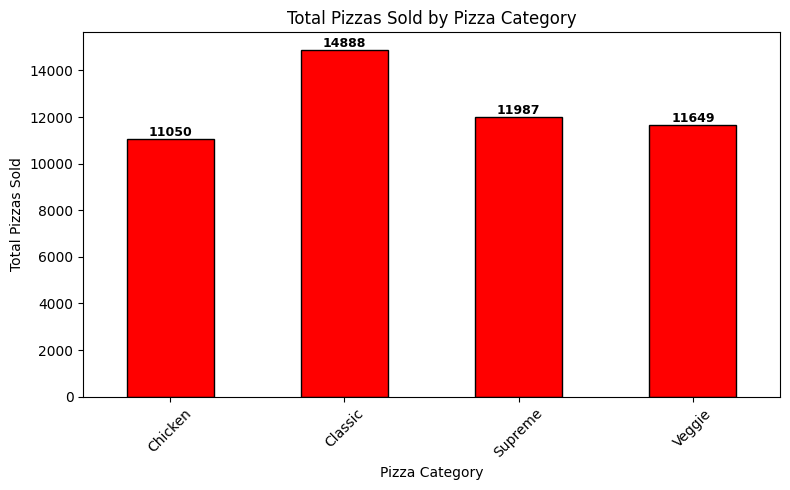

In [45]:
pizzas_by_category = df.groupby('pizza_category')['quantity'].sum()

ax = pizzas_by_category.plot(kind='bar', figsize=(8,5), color='red', edgecolor='black')

plt.title("Total Pizzas Sold by Pizza Category")
plt.xlabel("Pizza Category")
plt.ylabel("Total Pizzas Sold")
plt.xticks(rotation=45)

for i, val in enumerate(pizzas_by_category):
    plt.text(i, val + 5, str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

###Top Five Best-**Selling** Pizza- Total Orders

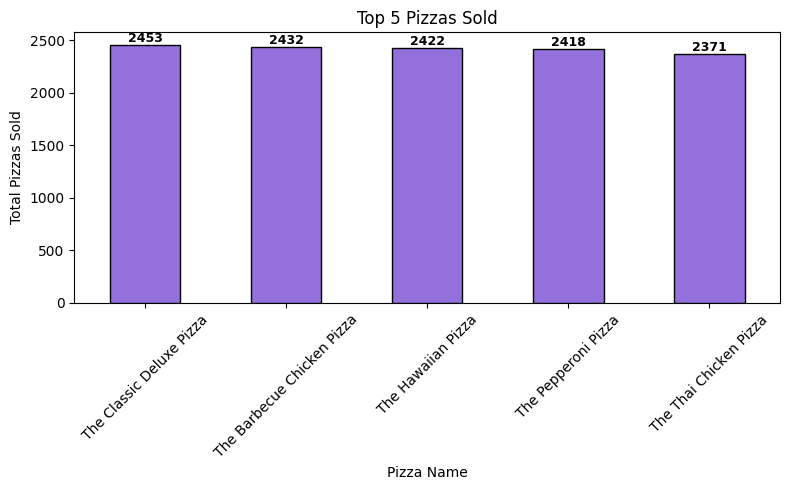

In [48]:
# Top 5 Best-Selling Pizzas - Total Qty

pizzas_by_name = df.groupby('pizza_name')['quantity'].sum()

top5 = pizzas_by_name.sort_values(ascending=False).head(5)

ax = top5.plot(kind='bar', figsize=(8,5), color='mediumpurple', edgecolor='black')

plt.title("Top 5 Pizzas Sold")
plt.xlabel("Pizza Name")
plt.ylabel("Total Pizzas Sold")
plt.xticks(rotation=45)

for i, val in enumerate(top5):
    plt.text(i, val + 2, str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

###Top Five Best Selling Pizza-Total Sales

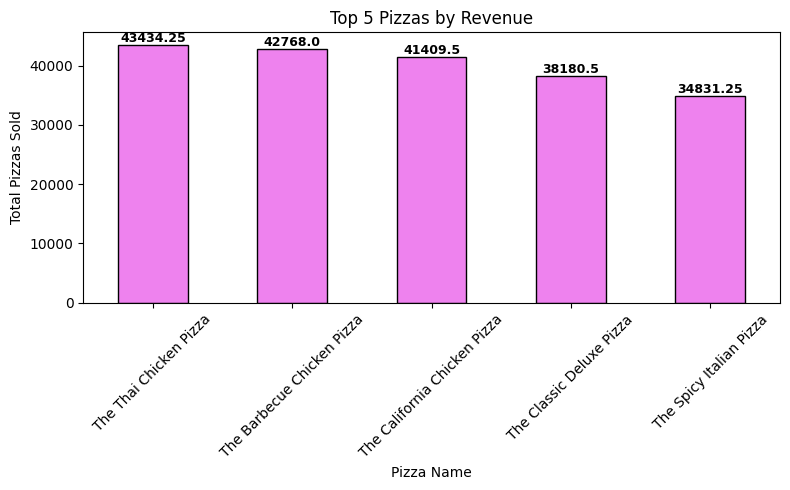

In [49]:
# Top 5 Pizzas by Revenue

pizzas_by_name = df.groupby('pizza_name')['total_price'].sum()

top5 = pizzas_by_name.sort_values(ascending=False).head(5)

ax = top5.plot(kind='bar', figsize=(8,5), color='violet', edgecolor='black')

plt.title("Top 5 Pizzas by Revenue")
plt.xlabel("Pizza Name")
plt.ylabel("Total Pizzas Sold")
plt.xticks(rotation=45)

for i, val in enumerate(top5):
    plt.text(i, val + 2, str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

###Bottom Five Best Selling Pizza-Total Sales

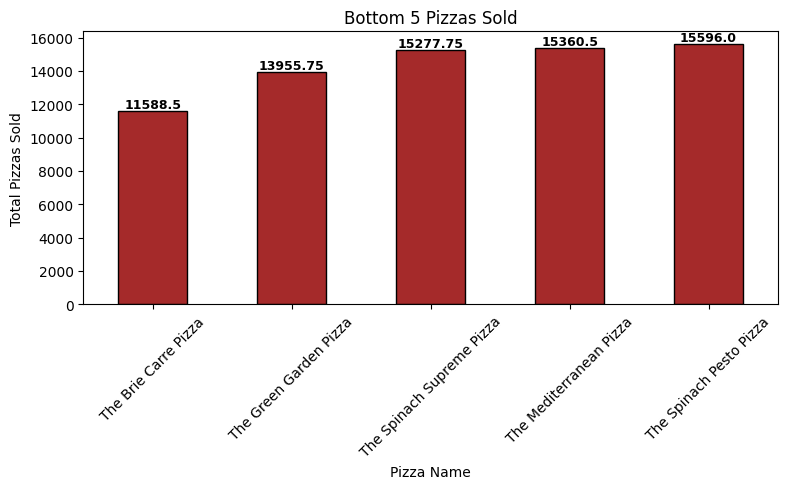

In [50]:
pizzas_by_name = df.groupby('pizza_name')['total_price'].sum()
bottom5 = pizzas_by_name.sort_values(ascending=True).head(5)

ax = bottom5.plot(
    kind='bar',
    figsize=(8, 5),
    color='brown',
    edgecolor='black'
)

plt.title("Bottom 5 Pizzas Sold")
plt.xlabel("Pizza Name")
plt.ylabel("Total Pizzas Sold")
plt.xticks(rotation=45)

for i, val in enumerate(bottom5):
    plt.text(
        i, val + 2, str(val),
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()